In [1]:
using BootstrapAsymptotics
using QuadGK
using Plots
using StableRNGs: StableRNG
using Statistics
using ProgressBars

In [2]:
κ1    =  2.0 / sqrt(3* pi)
κstar = 0.200364

γ_range = 10 .^ range(-1, stop=2, length=100)
Δ = 1.0
λ = 1.0

q0_list = []
q1_list = []

sample_over_teacher = 1.0

overlaps_list = []

algo = NoResampling()

for γ in ProgressBar(γ_range)
    Δ_add = BootstrapAsymptotics.get_additional_noise_from_kappas(κ1, κstar, γ)
    
    # 
    problem = BootstrapAsymptotics.RidgeOverparametrized(
    α       = sample_over_teacher / γ,
    Δ       = Δ + Δ_add,
    λ       = λ,
    ρ       = 1.0 - Δ_add,
    κ1      = κ1,
    κstar   = κstar,
    student_over_teacher_dim   = γ
    )

    result = BootstrapAsymptotics.state_evolution(
        problem, algo, algo
    )
   push!(q0_list, result.overlaps.Q[1, 1])
   push!(q1_list, result.overlaps.Q[1, 2])
   push!(overlaps_list, result.overlaps)
end

0.0%┣                                             ┫ 0/100 [00:02<-3:-21, -2s/it]
1.0%┣▍                                         ┫ 1/100 [00:04<Inf:Inf, InfGs/it]
100.0%┣██████████████████████████████████████████┫ 100/100 [00:04<00:00, 23it/s]
100.0%┣██████████████████████████████████████████┫ 100/100 [00:04<00:00, 23it/s]


In [8]:
scaling_list = []

for i in 1:length(overlaps_list)
    γ = γ_range[i]
    overlap = overlaps_list[i]
    Δ_add = BootstrapAsymptotics.get_additional_noise_from_kappas(κ1, κstar, γ)
    problem = BootstrapAsymptotics.RidgeOverparametrized(
    α       = sample_over_teacher / γ,
    Δ       = Δ + Δ_add,
    λ       = λ,
    ρ       = 1.0 - Δ_add,
    κ1      = κ1,
    κstar   = κstar,
    student_over_teacher_dim   = γ
    )

    scaling = BootstrapAsymptotics.get_scaling_gaussian_nll(overlap, problem)
    push!(scaling_list, scaling)
end



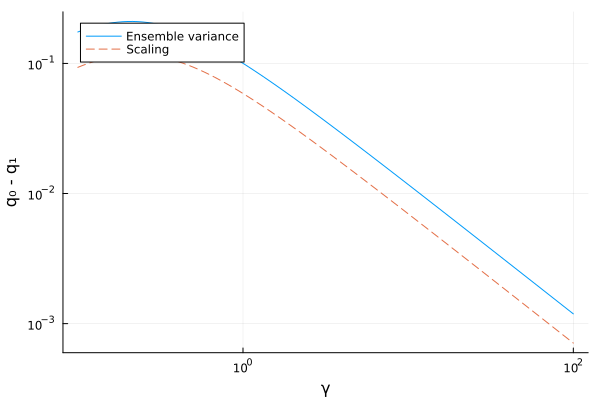

In [9]:
plot(γ_range, q0_list .- q1_list, label = "pre-scaling ensemble variance")

plot!(xscale=:log10, yscale=:log10, xlabel = "γ", ylabel = "q₀ - q₁", legend=:topleft)

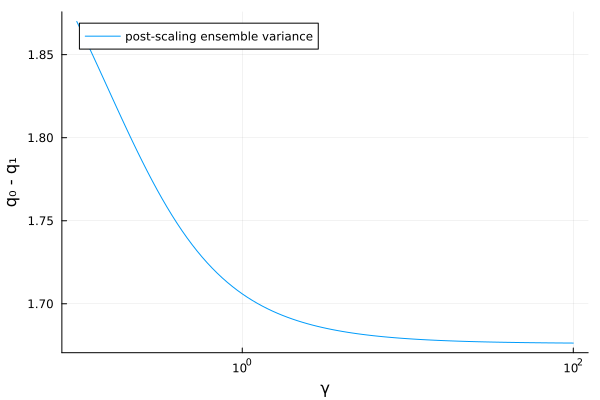

In [12]:
plot(γ_range, (q0_list - q1_list) ./ scaling_list, label = "post-scaling ensemble variance")
plot!(xscale=:log10, xlabel = "γ", ylabel = "q₀ - q₁", legend=:topleft)